# Качество патронов

При стрельбе по мишени качество патронов влияет на точность попаданий.

Патроны из одной партии неодинаковы. Например, может отличаться количество пороха из-за погрешности на производстве. Чем сильнее отличаются патроны, тем больше разброс попаданий на мишени.

**Цель:** хотим в среднем набирать как можно больше очков.

**Очки** начисляются за попадание в круги на мишени. Центры кругов совпадают, их диаметры: 5см, 10см, ..., 50см. За попадание в круг диаметра 5см дают 10 очков, за попадание между кругами диаметров 5см и 10см - 9 очков и так далее. Если не попал в круг диаметром 50см, то 0 очков.

**Bias-Variance:** при выборе патронов нам важен именно характер разброса, а не абсолютная близость попаданий к центру мишени во время эксперимента. Смещение стрелок сможет убрать позже, скорректировав прицельное приспособление. С разбросом так сделать не получится. Ситуация на нижней левой картинке для нас намного лучше, чем ситуация на правой верхней картинке.

<img src="https://www.cs.cornell.edu/courses/cs4780/2023fa/lectures/images/bias_variance/bullseye.png"  width="500">

**Эксперимент:** пришло две партии патронов от разных заводов, хотим определить какая лучше и есть ли статистически значимые отличия. Делаем по 100 выстрелов патронами из каждой партии. Получаем два набора данных, в каждом 100 пар координат (x, y) относительно центра мишени.

**Предположения:**
- Выстрелы считаем независимыми друг от друга;
- Отличия в характере разброса попаданий обусловлено только качеством патронов;
- Разброс попаданий симметричен относительно центра. Не будем рассматривать ситуации, когда есть выбросы в одну сторону.

В задании вам предстоит подумать над выбором метрик для оценки эксперимента, исследовать корректность работы разных способов оценки, выбрать наиболее подходящий и принять решение по данным конкретного эксперимента.

### Задание 1 (1 балл). Метрики

Предлагаем рассмотреть две метрики, характеризующие разброс попаданий:
- среднее расстояние от попаданий до центра, где центр вычисляется как среднее координат попаданий;
- среднее количество очков на мишени, которое заработал бы стрелок, если центр попаданий совпадал бы с центром мишени.

Напишите функции, которые помогут вычислять метрики эксперимента: `get_distances` и `get_scores`.


In [1]:
from collections import defaultdict
from typing import Dict, Tuple

import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
def get_distances(points: np.ndarray) -> np.ndarray:
    """Вычисляет расстояния от точек до их центра.

    :points (np.array): массив размера (N, 2) c координатами N точек
    :return (np.array): массив размера N.
    """
    return np.linalg.norm(points - np.mean(points, axis=0), axis=-1)


np.testing.assert_almost_equal(
    np.array([1, 1]),
    get_distances(np.array([[0, 0], [0, 2]])),
)
np.testing.assert_almost_equal(
    np.array([1.6666667, 0.33333333, 1.94365063]),
    get_distances(np.array([[0, 0], [-1, -1], [-3, -2]])),
)
print("тесты пройдены")

тесты пройдены


In [3]:
def get_scores(distances: np.ndarray) -> np.ndarray:
    """Вычисляет очки по расстояниям до центра мишени.

    :distances (np.array): массив размера N c расстояниями до центра мишени
    :return (np.array): массив размера N с количеством очков за попадания
    """
    thresholds = np.arange(5, 51, 5)
    scores = np.arange(10, -1, -1)
    
    return scores[np.digitize(distances, thresholds)]

np.testing.assert_almost_equal(
    np.array([10, 10,  9,  8,  7,  6,  5,  5,  4,  3,  2,  1,  0]),
    get_scores(np.linspace(0, 51, 13)),
)
print('тесты пройдены')

тесты пройдены


### Задание 2 (3 балла). Численные эксперименты

Согласно описанным выше метрикам проверяем гипотезу о равенстве средних. Рассмотрите **три подхода** для проверки гипотезы: t-test, бутстреп, собственный критерий на основе исторических данных. Для построения собственного критерия используйте данные о 1 млн выстрелов.

Данные генерируйте функцией `np.random.multivariate_normal((0, 0), ((var, 0), (0, var)))`. Для групп без эффекта используйте `var=200`, для экспериментов с эффектом рассмотрите **два случая**: `var=150` и `var=250`.

Для бутстрепа оценивайте вероятности ошибок, для остальных тестов постройте распределения p-value.
Уровень значимости $\alpha=0.05$. Размер групп 10. Если критерий будет работать некорректно, попробуйте увеличить размер групп до 100.

Итого, нужно написать код, который оценивает вероятности ошибок и строит распределения p-value для комбинаций следующих параметров:
- две метрики;
- три критерия;
- синтетические АА тесты и два варианта АB тестов;
- два размера групп.

In [4]:
def generate_data(
    size: Tuple[int, ...],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    a, b = np.random.multivariate_normal(
        [0, 0], [[200, 0], [0, 200]], size=(2, *size)
    )
    b_effect1 = np.random.multivariate_normal(
        [0, 0], [[150, 0], [0, 150]], size=size
    )
    b_effect2 = np.random.multivariate_normal(
        [0, 0], [[250, 0], [0, 250]], size=size
    )

    dists_a = get_distances(a)
    dists_b = get_distances(b)
    dists_b_effect1 = get_distances(b_effect1)
    dists_b_effect2 = get_distances(b_effect2)

    return dists_a, dists_b, dists_b_effect1, dists_b_effect2

#### T-test

In [5]:
def plot_pvalue_distribution_power(
    dict_pvalues: Dict[str, np.ndarray],
    alpha: float = 0.01,
    title: str = "Empirical p-value distribution",
):
    plt.figure(figsize=(12, 8))
    X = np.linspace(0, 1, 1000)
    for key, pvalues in dict_pvalues.items():
        Y = np.searchsorted(np.sort(pvalues), X, side="right") / len(pvalues)
        prob_p = np.mean(np.array(pvalues) < alpha)
        plt.plot(X, Y, label=f"{key}, prob_p={prob_p:0.2f}")

    plt.plot([alpha, alpha], [0, 1], "--k", alpha=0.8)
    plt.plot([0, 1], [0, 1], "--k", alpha=0.8)
    plt.title(title, size=16)
    plt.xlabel("p-value", size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

sample_size: 10


100%|██████████| 1000/1000 [00:05<00:00, 174.56it/s]


sample_size: 100


100%|██████████| 1000/1000 [00:05<00:00, 195.82it/s]


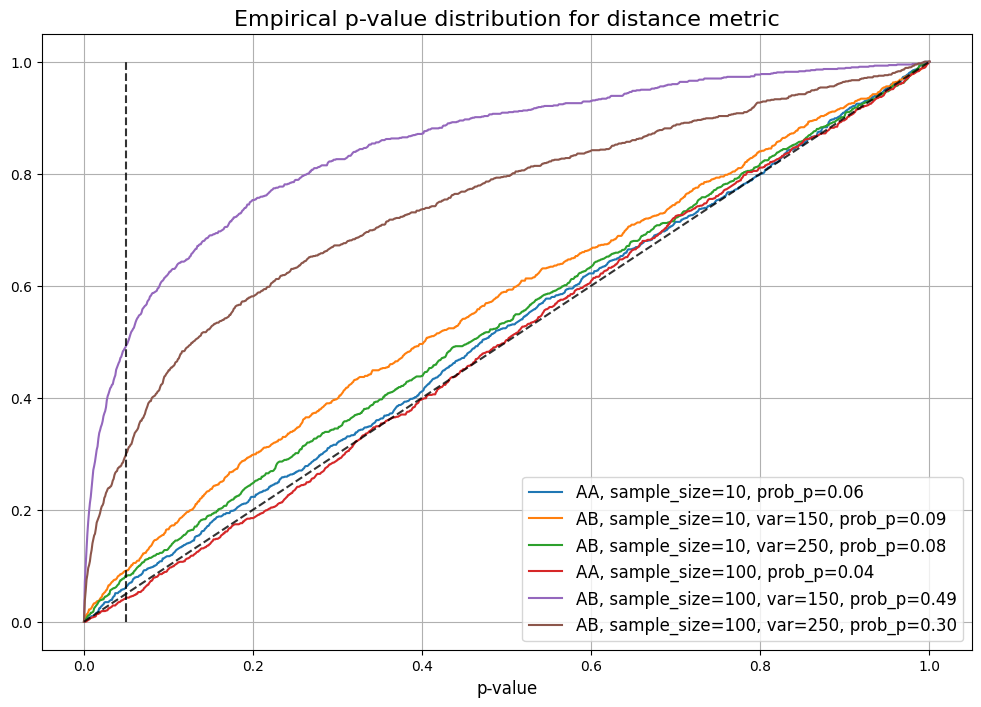

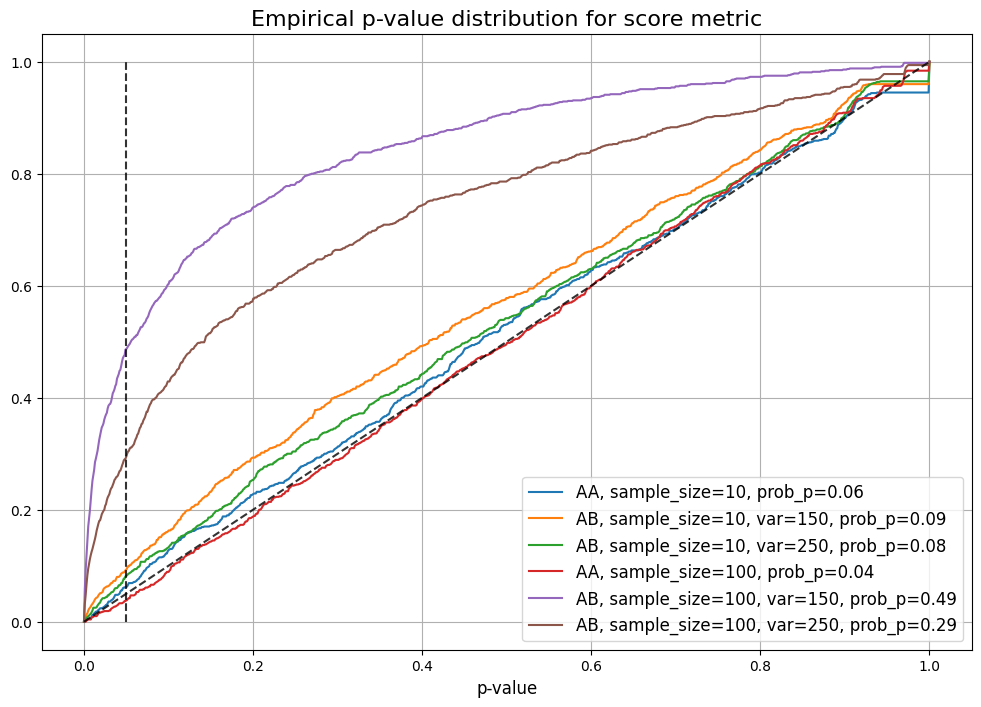

In [6]:
n_experiments = 1000

dict_pvalues_dist = defaultdict(list)
dict_pvalues_score = defaultdict(list)

for sample_size in [10, 100]:
    print("sample_size:", sample_size)
    a, b1, b2, b3 = generate_data((n_experiments, sample_size))
    for i in tqdm(range(n_experiments)):
        dict_pvalues_dist[f"AA, sample_size={sample_size}"].append(
            stats.ttest_ind(a[i], b1[i]).pvalue
        )
        dict_pvalues_dist[f"AB, sample_size={sample_size}, var=150"].append(
            stats.ttest_ind(a[i], b2[i]).pvalue
        )
        dict_pvalues_dist[f"AB, sample_size={sample_size}, var=250"].append(
            stats.ttest_ind(a[i], b3[i]).pvalue
        )

        dict_pvalues_score[f"AA, sample_size={sample_size}"].append(
            stats.ttest_ind(get_scores(a[i]), get_scores(b1[i])).pvalue
        )
        dict_pvalues_score[f"AB, sample_size={sample_size}, var=150"].append(
            stats.ttest_ind(get_scores(a[i]), get_scores(b2[i])).pvalue
        )
        dict_pvalues_score[f"AB, sample_size={sample_size}, var=250"].append(
            stats.ttest_ind(get_scores(a[i]), get_scores(b3[i])).pvalue
        )

plot_pvalue_distribution_power(
    dict_pvalues_dist, 0.05, "Empirical p-value distribution for distance metric"
)
plot_pvalue_distribution_power(
    dict_pvalues_score, 0.05, "Empirical p-value distribution for score metric"
)

#### Bootstrap

In [7]:
def get_quantile_ci(pvalues: np.ndarray, alpha: float = 0.05) -> Tuple[float, float]:
    return np.quantile(pvalues, [alpha / 2, (1 - alpha / 2)])

In [8]:
n_experiments = 10000

dict_pvalues_dist = defaultdict(list)
dict_pvalues_score = defaultdict(list)

for sample_size in [10, 100]:
    a, b1, b2, b3 = generate_data((n_experiments * sample_size,))
    print("sample_size:", sample_size)
    for _ in tqdm(range(n_experiments)):
        a_sample = np.random.choice(a, sample_size)
        b1_sample = np.random.choice(b1, sample_size)
        b2_sample = np.random.choice(b2, sample_size)
        b3_sample = np.random.choice(b3, sample_size)
        

        dict_pvalues_dist[f"AA, sample_size={sample_size}"].append(
            np.mean(a_sample) - np.mean(b1_sample)
        )
        dict_pvalues_dist[f"AB, sample_size={sample_size}, var=150"].append(
            np.mean(a_sample) - np.mean(b2_sample)
        )
        dict_pvalues_dist[f"AB, sample_size={sample_size}, var=250"].append(
            np.mean(a_sample) - np.mean(b3_sample)
        )

        dict_pvalues_score[f"AA, sample_size={sample_size}"].append(
            np.mean(get_scores(a_sample)) - np.mean(get_scores(b1_sample))
        )
        dict_pvalues_score[f"AB, sample_size={sample_size}, var=150"].append(
            np.mean(get_scores(a_sample)) - np.mean(get_scores(b2_sample))
        )
        dict_pvalues_score[f"AB, sample_size={sample_size}, var=250"].append(
            np.mean(get_scores(a_sample)) - np.mean(get_scores(b3_sample))
        )

print()
for key, pvalues in dict_pvalues_dist.items():
    ci = get_quantile_ci(np.array(pvalues))
    print(f"{key}: {ci}")
print()
for key, pvalues in dict_pvalues_score.items():
    ci = get_quantile_ci(np.array(pvalues))
    print(f"{key}: {ci}")

sample_size: 10


100%|██████████| 10000/10000 [00:00<00:00, 10162.30it/s]


sample_size: 100


100%|██████████| 10000/10000 [00:01<00:00, 9596.33it/s]


AA, sample_size=10: [-8.14905462  8.03095885]
AB, sample_size=10, var=150: [-5.36163729  9.85163853]
AB, sample_size=10, var=250: [-10.92947398   6.46074708]
AA, sample_size=100: [-2.55246192  2.52583949]
AB, sample_size=100, var=150: [-0.01361228  4.73782035]
AB, sample_size=100, var=250: [-4.79832621  0.63767583]

AA, sample_size=10: [-1.6  1.6]
AB, sample_size=10, var=150: [-2.   1.1]
AB, sample_size=10, var=250: [-1.3  2.2]
AA, sample_size=100: [-0.51  0.51]
AB, sample_size=100, var=150: [-0.96  0.01]
AB, sample_size=100, var=250: [-0.14  0.96]


#### Historical data

In [9]:
stat_size = 10_000
hist_size = 1_000_000
batch_size = 100

history = np.random.multivariate_normal([0, 0], [[200, 0], [0, 200]], size=(1_000_000))
history_dists = get_distances(history)
history_scores = get_scores(history_dists)

statistics_dists = defaultdict(list)
statistics_scores = defaultdict(list)

for sample_size in [10, 100]:
    for _ in tqdm(range(stat_size // batch_size)):
        history_sample = np.random.choice(
            history_dists,
            size=(batch_size, 2, sample_size),
            replace=False
        )
        a_mean = history_sample[:, 0, :].mean(axis=1)
        b_mean = history_sample[:, 1, :].mean(axis=1)

        a_score_mean = get_scores(history_sample[:, 0, :]).mean(axis=1)
        b_score_mean = get_scores(history_sample[:, 1, :]).mean(axis=1)
        
        statistics_dists[sample_size].extend(list(b_mean - a_mean))
        statistics_scores[sample_size].extend(list(a_score_mean - b_score_mean))

    statistics_dists[sample_size] = np.array(statistics_dists[sample_size])
    statistics_scores[sample_size] = np.array(statistics_scores[sample_size])

100%|██████████| 100/100 [00:01<00:00, 76.15it/s]


In [10]:
def stat_test(a: np.ndarray, b: np.ndarray, stat_data: np.ndarray) -> float:
    est = np.mean(a) - np.mean(b)
    statistic = np.mean(stat_data < est)

    return 2 * min(statistic, 1 - statistic)

sample_size: 10


100%|██████████| 10000/10000 [00:01<00:00, 9016.83it/s]


sample_size: 100


100%|██████████| 10000/10000 [00:01<00:00, 8625.66it/s]


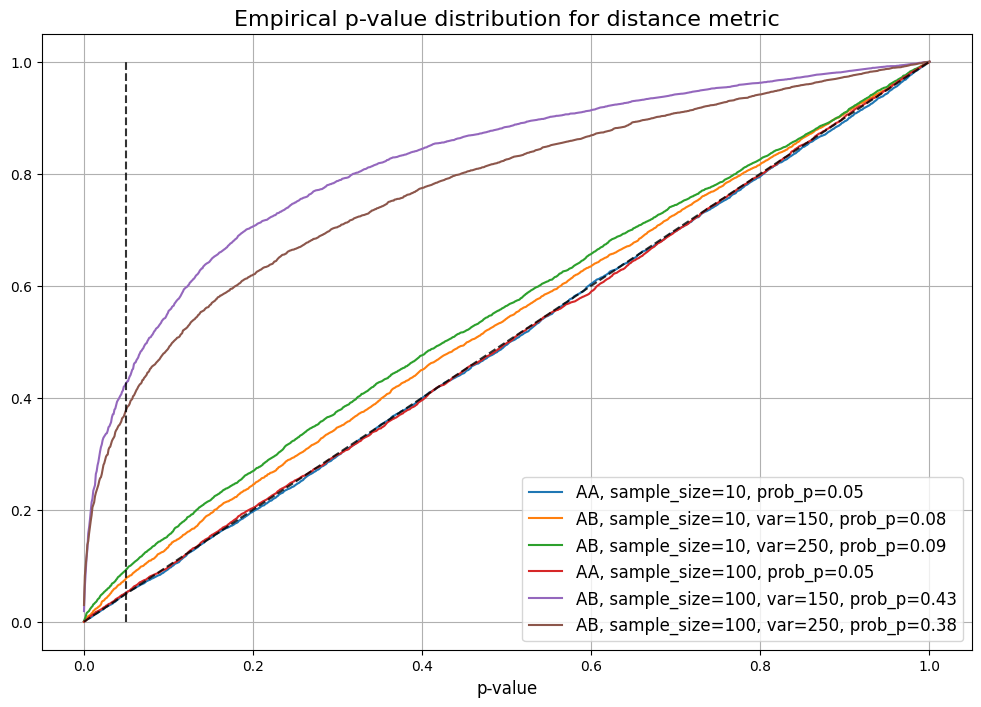

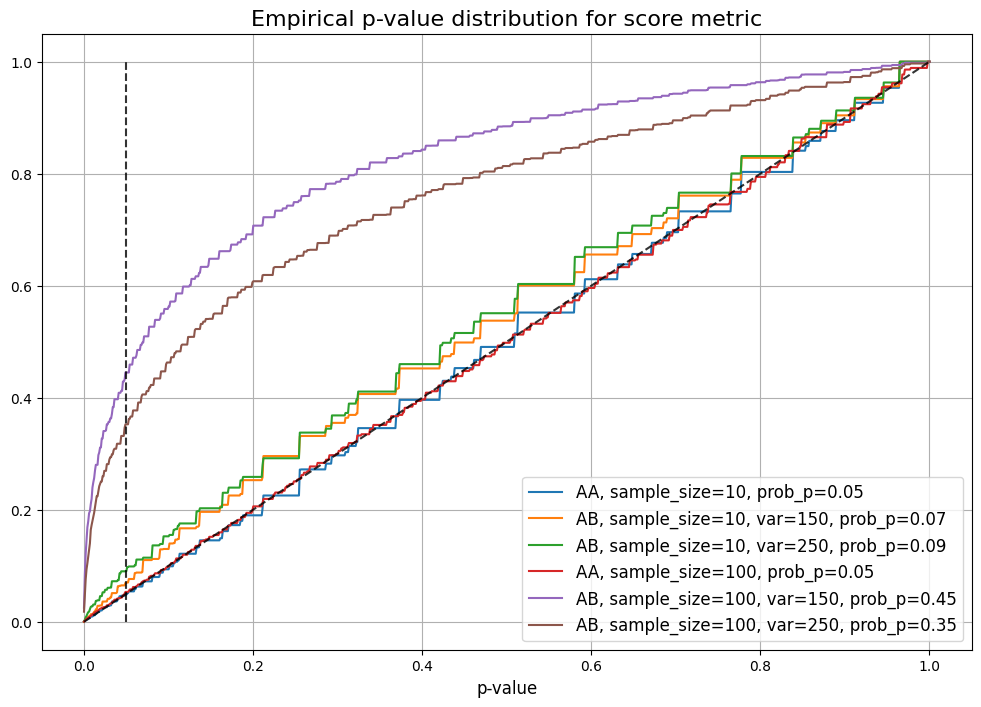

In [11]:
n_experiments = 10000

dict_pvalues_dist = defaultdict(list)
dict_pvalues_score = defaultdict(list)

for sample_size in [10, 100]:
    print("sample_size:", sample_size)
    a, b1, b2, b3 = generate_data((n_experiments, sample_size))
    for i in tqdm(range(n_experiments)):
        dict_pvalues_dist[f"AA, sample_size={sample_size}"].append(
            stat_test(a[i], b1[i], statistics_dists[sample_size])
        )
        dict_pvalues_dist[f"AB, sample_size={sample_size}, var=150"].append(
            stat_test(a[i], b2[i], statistics_dists[sample_size])
        )
        dict_pvalues_dist[f"AB, sample_size={sample_size}, var=250"].append(
            stat_test(a[i], b3[i], statistics_dists[sample_size])
        )

        dict_pvalues_score[f"AA, sample_size={sample_size}"].append(
            stat_test(
                get_scores(a[i]), get_scores(b1[i]), statistics_scores[sample_size]
            )
        )
        dict_pvalues_score[f"AB, sample_size={sample_size}, var=150"].append(
            stat_test(
                get_scores(a[i]), get_scores(b2[i]), statistics_scores[sample_size]
            )
        )
        dict_pvalues_score[f"AB, sample_size={sample_size}, var=250"].append(
            stat_test(
                get_scores(a[i]), get_scores(b3[i]), statistics_scores[sample_size]
            )
        )

plot_pvalue_distribution_power(
    dict_pvalues_dist, 0.05, "Empirical p-value distribution for distance metric"
)
plot_pvalue_distribution_power(
    dict_pvalues_score, 0.05, "Empirical p-value distribution for score metric"
)

### Задание 3 (2 балла). Анализ численных экспериментов.

Напишите свои мысли по следующим вопросам:

**Блок 1:**
- Какие критерии для каких метрик контролируют вероятность ошибки первого рода на заданном уровне при размере групп равным 10?
- Если вероятность ошибки первого рода не контролируется, то почему это может происходить? Какие предположения нарушены?
- Помогло ли увеличение размера групп получить контроль над вероятностью ошибок первого рода?

**Блок 2:**
- Какие особенности в распределениях p-value наблюдаются? Чем они вызваны?
- Какая из двух метрик имеет большую мощность? Как думаете, почему это так?
- Для синтетических АB экспериментов рассматривалось два варианта эффекта $200\pm50$. Мощности критериев для этих вариантов отличаются? Если да, то почему?

#### Блок 1
- Какие критерии для каких метрик контролируют вероятность ошибки первого рода на заданном уровне при размере групп равным 10?
  В t-test и Статистическом критериях можно строить статистику для обеих метрик, и сравнивать вероятность полученной статистики с заранее заданным уровнем значимости. В бутстрапе проверяется факт вхождения нуля в доверительный интервал с заранее заданным уровнем значимости
- Если не контролировать вероятность ошибки первого рода, мы можем нарушать предположение о верности нулевой гипотезы. В таком
  случае мы не можем точно сказать, что различия в попаданиях обусловлены качеством патронов
- Увеличение размера групп не сильно увеличило контроль над вероятностью ошибок первого рода для каждого из критериев


#### Блок 2
- Как и ожидалось, без эффекта p-value распределены равномерно, а с эффектом - смещены в сторону нуля, и это смещение 
  увеличивается с увеличением эффекта или размера групп
- Обе метрики показывают примерно одинаковую мощность на данных критериях. Я считаю, что это обусловленно тем, что они имеют
  похожие природы, а одна является дискретной версией другой
- Мощности критерия при сравнении с эффектом $-50$ больше, чем при сравнении с эффектом $+50$. Это можно обосновать следующим
  образом: Пусть $X, Y, Z$ - случайные величины с нулевым матожиданием и дисперсиями $150, 200, 250$ соответственно. Тогда
  $\mathbb{E} \sqrt{X_1^2 + X_2^2} = \sqrt(300) \approx 17.32$, $\mathbb{E} \sqrt{Y_1^2 + Y_2^2} = 20$, $\mathbb{E} \sqrt{Z_1^2 + Z_2^2} = \sqrt(500) \approx 22.36$ Заметим, что $\mathbb{E} (\sqrt{Z_1^2 + Z_2^2} - \sqrt{Y_1^2 + Y_2^2}) > \mathbb{E} (\sqrt{Y_1^2 + Y_2^2} - \sqrt{X_1^2 + X_2^2})$, что объясняет различие в мощности

### Задание 4 (2 балла). Дизайн эксперимента

По-хорошему нужно фиксировать все параметры эксперимента до его запуска. Опираясь на результаты численных экспериментов, определите что и как будете оценивать в эксперименте. Обоснуйте свой выбор.

- какая метрика?
- какой критерий?
- какой размер групп, 10 или 100?
- как будет приниматься решение? В итоге нужно сказать есть ли значимые отличия патронов из группы B. При каких условиях скажем, что они значимо лучше? При каких условиях скажем, что они значимо хуже?

- Я больше склоняюсь к использованию метрики очков за попадания, так как именно её мы стараемся максимизировать
- Я не вижу смысли использовать бутстрап, так как на синтетических данных он показал себя довольно плохо: на данных с 
  искусственным эффектом 0 попадал в доверительный интервал. Выбирая между t-test и Статистическим критерием, я предпочитаю t-test, так как оба критерия показывают похожий результат, но t-test не требует больших исторических данных
- Я бы выбрал размер групп 100, так как это увеличит мощность критерия, и у нас есть как раз 100 точек в выборке
- Решение будет приниматься на основе p-value двухстороннего t-testа. Если p-value меньше $\alpha = 0.05$, и можем утверждать, 
  что эти патроны лучше или хуже в зависимости от знака разности средних

### Задание 5 (2 балла). Оценка эксперимента

Ниже приведены данные эксперимента. Проверьте для каждой из метрик какая серия выстрелов лучше и есть ли статистически значимые отличия. Есть ли в этих результатах что-то необычное? Объяснить получившийся результат.

Какие патроны в итоге будем использовать в дальнейшем?

In [12]:
a = np.array([[-5.866, -4.715], [1.147, -11.187], [-3.091, -10.793], [-10.99, 26.154], [-9.979, -1.217], [4.072, -1.858], [-13.898, -12.994], [16.963, -4.828], [-24.87, 0.723], [-8.088, -9.907], [-13.224, 21.701], [27.965, -6.154], [-1.903, -2.964], [-10.845, 0.565], [8.652, -3.731], [7.315, 9.711], [15.563, -1.303], [-5.893, -3.109], [-0.251, -16.834], [-15.353, -15.202], [0.203, -1.261], [-9.549, 22.481], [-6.328, -7.363], [-9.809, 17.943], [19.805, -8.81], [5.467, 8.047], [-20.176, -25.893], [-21.986, 34.126], [3.257, 3.638], [-3.079, -7.312], [25.643, -12.654], [3.736, 32.391], [-5.356, -1.713], [-5.216, -17.179], [-3.341, 17.842], [-4.65, 0.408], [-18.106, -34.23], [14.179, -21.627], [-7.998, -6.178], [20.697, -19.382], [10.831, -29.149], [9.675, 14.98], [2.55, 3.798], [1.543, 12.509], [-9.679, 36.311], [-8.324, -3.295], [-4.522, -2.125], [-12.494, -7.173], [-27.934, -33.084], [-22.709, 0.899], [19.9, -25.882], [-4.468, -24.142], [8.319, -7.338], [41.025, -12.874], [16.177, -5.175], [-5.425, 7.232], [-17.21, 10.717], [-8.809, 8.35], [9.002, -30.119], [-10.48, -0.81], [-9.879, 5.959], [3.923, -4.97], [9.438, -0.755], [-9.317, 11.712], [-3.427, 10.787], [-9.706, -8.341], [-7.498, -0.108], [-28.264, 3.045], [-4.81, -6.383], [-20.438, -0.403], [1.589, 9.564], [-3.477, 5.622], [6.558, -7.772], [0.12, -25.826], [-18.727, 2.929], [3.497, -4.788], [-0.717, 17.057], [-17.905, 4.305], [-27.941, -11.039], [5.36, -1.829], [-16.16, 24.17], [-18.102, -22.828], [0.972, -14.005], [10.092, -1.818], [2.197, 5.93], [14.72, 0.708], [-5.767, -10.803], [-2.417, 7.301], [5.892, -16.155], [4.123, -12.12], [-7.731, 32.926], [-9.628, 19.876], [-10.329, 15.294], [-1.14, 1.786], [26.765, 7.602], [-6.902, -9.195], [-9.844, 20.696], [12.932, -7.647], [1.322, 25.226], [1.663, -4.952]])
b = np.array([[6.21, 0.841], [0.805, 4.536], [4.94, 3.828], [-2.227, -2.293], [-1.663, 1.164], [-2.571, 2.117], [-3.249, -0.434], [-0.121, 2.075], [-3.376, 0.129], [-95.27, 134.413], [-4.98, 2.595], [3.982, -2.517], [-5.179, -1.886], [1.475, -6.23], [-0.27, 5.51], [-1.961, 1.665], [2.085, -1.22], [-166.325, -15.217], [0.134, 3.376], [-3.227, 3.136], [1.973, -0.872], [156.095, 48.118], [3.768, 2.564], [2.718, 0.994], [-0.697, -3.733], [1.422, 1.829], [27.669, -166.984], [4.823, -3.681], [50.888, 136.502], [-109.444, -136.475], [-138.735, -55.554], [-1.087, 3.97], [-97.584, 111.349], [-155.121, 19.304], [123.361, -132.001], [2.631, -1.883], [-4.754, -6.464], [-69.211, 132.216], [1.867, 3.96], [-1.965, 162.021], [-3.193, -1.88], [-168.409, 22.158], [174.981, 53.034], [0.404, -1.178], [0.121, -5.067], [3.419, 2.077], [-0.355, -5.672], [-0.813, 4.476], [2.517, -3.208], [1.668, 4.524], [2.655, -1.362], [-3.914, 0.614], [-0.723, 3.923], [-5.958, -5.434], [9.736, 2.508], [4.094, 4.761], [-3.827, -4.1], [4.701, -4.168], [2.758, -0.903], [-2.702, -6.112], [2.258, 1.384], [0.368, -1.365], [-5.202, 2.35], [-4.242, 3.591], [-3.597, -0.703], [-0.211, 2.931], [3.414, 1.217], [-2.175, 2.435], [-3.886, 3.047], [3.506, -3.004], [3.719, -2.321], [-3.907, 2.552], [3.429, -2.206], [-5.581, -8.112], [6.196, -0.75], [1.783, 4.966], [-2.453, -5.72], [-0.311, -0.157], [0.412, -1.849], [0.072, -7.887], [-1.202, -1.701], [-1.875, 0.902], [-2.754, -4.749], [-3.709, 0.253], [-0.553, -0.965], [-2.199, 3.088], [5.322, -6.595], [-1.903, -0.302], [-1.959, -4.57], [-0.953, -2.954], [-3.322, 1.249], [3.996, 1.182], [3.242, -2.823], [2.02, 0.029], [-0.101, -0.058], [3.235, -3.879], [-0.9, 6.376], [-0.473, -2.205], [4.746, -4.002], [-3.833, 5.522]])

In [13]:
# В первую очередь, настроим прицел на центр мишени:
a = a - np.mean(a, axis=0)
b = b - np.mean(b, axis=0)

a_scores = get_scores(get_distances(a))
b_scores = get_scores(get_distances(b))

t, p = stats.ttest_ind(a_scores, b_scores)
print(f"p-value: {p:.2f}")
if p > 0.05:
    print("Нулевая гипотеза не отвергается: p-value > 0.05")
else:
    print("Нулевая гипотеза отвергается: p-value <= 0.05")
    if t > 0:
        print("Выборка A ближе к центру мишени, используем патроны A")
    else:
        print("Выборка B ближе к центру мишени, используем патроны B")

p-value: 0.04
Нулевая гипотеза отвергается: p-value <= 0.05
Выборка B ближе к центру мишени, используем патроны B


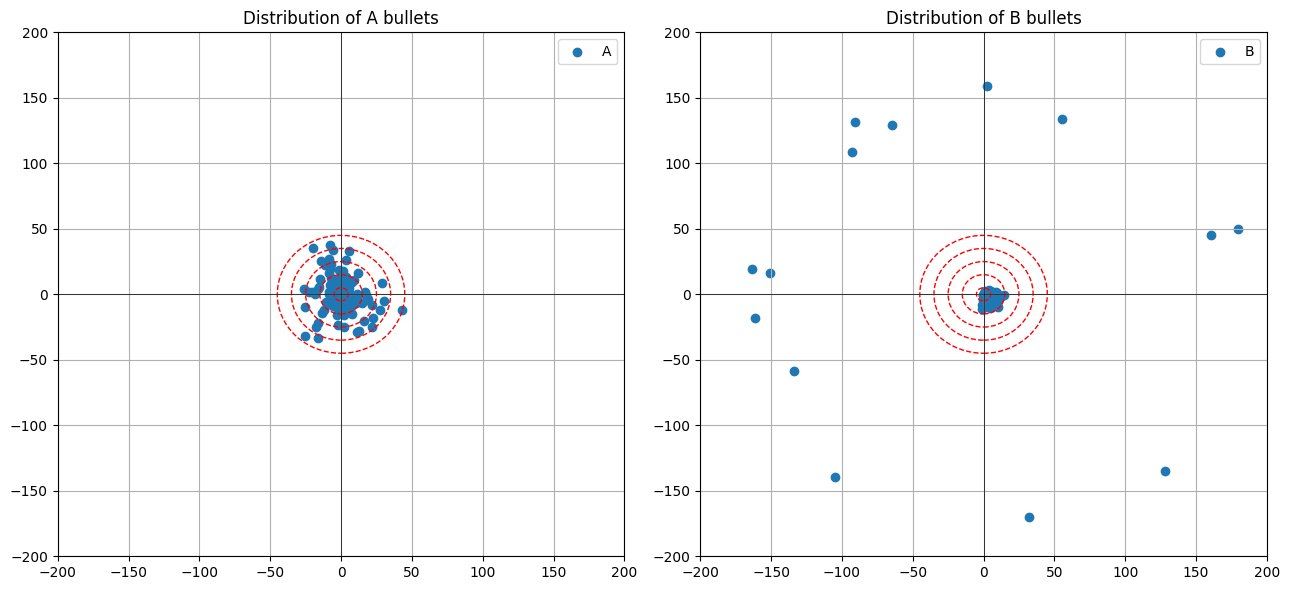

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 6))
aim_size = 200

def add_aims(ax):
    for radius in range(5, 51, 10):
        circle = plt.Circle((0, 0), radius, color='red', fill=False, linestyle='--')
        ax.add_artist(circle)


ax[0].scatter(a[:, 0], a[:, 1], label="A")
add_aims(ax[0])
ax[0].legend()
ax[0].set_title("Distribution of A bullets")
ax[0].set_xlim(-aim_size, aim_size)
ax[0].set_ylim(-aim_size, aim_size)
ax[0].axhline(0, color='black', linewidth=0.5)
ax[0].axvline(0, color='black', linewidth=0.5)
ax[0].grid()

# Plot for sample B
ax[1].scatter(b[:, 0], b[:, 1], label="B")
add_aims(ax[1])
ax[1].legend()
ax[1].set_title("Distribution of B bullets")
ax[1].set_xlim(-aim_size, aim_size)
ax[1].set_ylim(-aim_size, aim_size)
ax[1].axhline(0, color='black', linewidth=0.5)
ax[1].axvline(0, color='black', linewidth=0.5)
ax[1].grid()

plt.tight_layout()
plt.show()